In [1]:
import os

import torch
from sclsd.train import LSD
from sclsd.core import LSDConfig
from sclsd.utils import set_all_seeds
from sclsd.utils.seed import clear_pyro_state
import scanpy as sc

/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configure computational device
# Using GPU for faster training (change to 'cpu' if no GPU available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed for reproducibility
SEED = 42
set_all_seeds(SEED)


Using device: cuda


In [3]:
# Load training data
DATA_PATH = "../../Zenodo/Zebrafish/preprocessed_adata_train.h5ad"
adata = sc.read(DATA_PATH)


In [4]:
# Configure optimization hyperparameters
cfg = LSDConfig()
cfg.model.layer_dims.potential = [16, 16]
cfg.optimizer.adam.lr = 2e-3
cfg.optimizer.adam.T_0 = 60
cfg.walks.path_len = 40
cfg.walks.num_walks = 2048


# Initialize LSD model
lsd = LSD(
    adata,
    cfg,
    device=device,

)
lsd.set_prior_transition(prior_transition=adata.obsp["prior_transition"])
lsd.prepare_walks()

[LSD] Prior transition matrix set from user input.


Training Epochs: 100%|██████████| 250/250 [14:48<00:00,  3.56s/it, -ELBO=0.1559, Potential Metric=0.1264, Entropy Metric=0.0691]


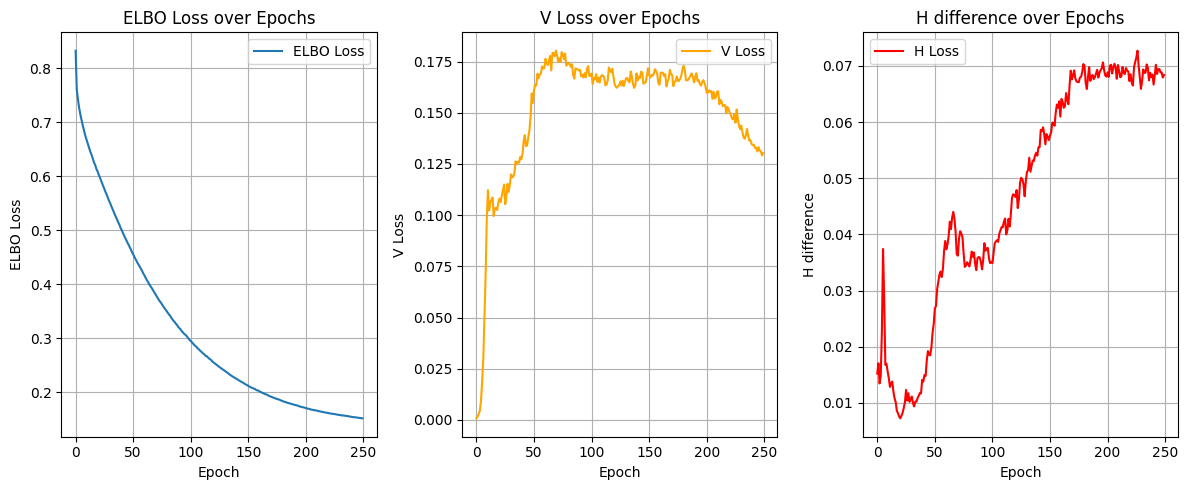


Training completed! Model saved to ./model


In [5]:
# Clear parameter store to ensure clean training
clear_pyro_state()

# Define model directory
MODEL_DIR = "./model"
os.makedirs(MODEL_DIR, exist_ok=True)

# Train the model
lsd.train(
    num_epochs=250,           # Number of training epochs
    save_dir=MODEL_DIR,       # Directory to save checkpoints
    save_interval=50          # Save checkpoint every 50 epochs
)

print(f"\nTraining completed! Model saved to {MODEL_DIR}")